# QMSSGR5074 - Project 3


### Your Group ID: Group 9
### Your UNIs: awt2135, cf3074
### Your Full Names: Aoife Wen-Yi Turner, Chenyiwei Fu
### Public GitHub Repo: https://github.com/aoifeturner/Project-3-QMSS

## Description

## Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - Acquire the Stanford Sentiment Treebank dataset.  
   - Split into training, validation and test sets with stratified sampling to preserve class balance.  
   - Clearly document your splitting strategy and resulting dataset sizes.

2. **Text Cleaning & Tokenization**  
   - Implement a reusable preprocessing pipeline that handles at least:  
     - HTML removal, lowercasing, punctuation stripping  
     - Vocabulary pruning (e.g., rare words threshold)  
     - Tokenization (character- or word-level)  
   - Expose this as a function/class so it can be saved and re-loaded for inference.

3. **Feature Extraction**  
   - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
   - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
   - Save each preprocessor (vectorizer/tokenizer) to disk.

---

## Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - Visualize the number of positive vs. negative reviews.  
   - Compute descriptive statistics on review lengths (mean, median, IQR).  

2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

---

## Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Train at least two linear models on your TF-IDF features (e.g., logistic regression, linear SVM).  
   - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.  

2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

---

## Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Build an embedding layer + a dense MLP classifier.  
   - Ensure you freeze vs. unfreeze embeddings in separate runs.

2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.

3. **Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

---

## Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - Retrain one network using pre-trained GloVe (or FastText) embeddings.  
   - Compare results against your from-scratch embedding runs.

2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).


---

## Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.  
   - Describe your search space and stopping criteria.

2. **Results Analysis**  
   - Report the best hyperparameter configuration found.  
   - Plot validation-loss (or metric) vs. trials to illustrate tuning behavior.

---

## Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - Tabulate test-set performance for **all** models (traditional, neural, transfer-learned).  
   - Highlight top‐performing model overall and top in each category.

2. **Statistical Significance**  
   - Perform a significance test (e.g., McNemar’s test) between your best two models.  

3. **Error Analysis**  
   - Identify at least 20 examples your best model misclassified.  
   - For a sample of 5, provide the raw text, predicted vs. true label, and a short discussion of each error—what linguistic artifact might have confused the model?

---

## Part 8 – Optional Challenge Extensions

- Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.  
- Integrate a sentiment lexicon feature (e.g., VADER scores) into your models and assess whether it improves predictions.  
- Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews.

---

In [ ]:
# Run this cell first every session, these are needed for below
!pip install optuna googletrans==4.0.0rc1 transformers -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that

## Note for Grader: Please use a T4 GPU to run our code, given the inclusion of BERT

## Part 1 – Data Ingestion & Preprocessing


1. **Data Loading**  
    - Acquire the Stanford Sentiment Treebank dataset.
    - Split into training, validation, and test sets with stratified sampling to preserve class balance.
    - Clearly document your splitting strategy and resulting dataset sizes.
    

In [ ]:
# Load data (example)
import pandas as pd


# IMPORT DATA
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git

Cloning into 'SST-2-sentiment-analysis'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 85 (delta 44), reused 29 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 478.79 KiB | 5.70 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [ ]:
from sklearn.model_selection import train_test_split

df_train_full = pd.read_csv('/content/SST-2-sentiment-analysis/data/train.tsv', sep='\t', header=None)
df_test       = pd.read_csv('/content/SST-2-sentiment-analysis/data/dev.tsv',   sep='\t', header=None)

df_train, df_val = train_test_split(df_train_full, test_size=0.1, random_state=42, stratify=df_train_full[0])
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 6228, Val: 692, Test: 872


In [ ]:
df_train.shape

(6228, 2)


2. **Text Cleaning & Tokenization**  
    - Implement a reusable preprocessing pipeline that handles at least:  
        - HTML removal, lowercasing, punctuation stripping  
        - Vocabulary pruning (e.g., rare words threshold)  
        - Tokenization (character- or word-level)  
    - Expose this as a function/class so it can be saved and re-loaded for inference.
    

In [ ]:
import re
from sklearn.feature_extraction.text import CountVectorizer

def clean_text(text):

    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'\W+', ' ', text.lower())
    return text.strip()

l1 = [df_train, df_test, df_val]
for df in l1:
    df[1] = df[1].apply(clean_text)
    print(df.head())

   0                                                  1
0  1  this bracingly truthful antidote to hollywood ...
1  1  nicks sustains the level of exaggerated styliz...
2  1    the film is small in scope yet perfectly formed
3  0  does n t get the job done running off the limi...
4  0                a moving picture that does not move
   0                                                  1
0  0                         one long string of cliches
1  0  if you ve ever entertained the notion of doing...
2  0  k 19 exploits our substantial collective fear ...
3  0  it s played in the most straight faced fashion...
4  1  there is a fabric of complex ideas here and fe...
   0                                                  1
0  1  much has been written about those years when t...
1  1  adaptation s success in engaging the audience ...
2  0  sade achieves the near impossible it turns the...
3  1  great over the top moviemaking if you re in a ...
4  0                          the comedy is none

given that the data from the repository is already preprocessed and splitted into train test val, here is how it was done:


Stratified sampling was used during the splitting process to preserve the original class distribution of the sentiment labels across all subsets. This helps maintain consistency between the training and evaluation data and also avoid class imbalance.

To verify this, we could examined the class distribution in each split using value_counts(). The proportions of each sentiment class (e.g., positive and negative) are similar across the training, validation, and test sets, confirming that stratification was applied correctly.




3. **Feature Extraction**  
    - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
    - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
    - Save each preprocessor (vectorizer/tokenizer) to disk.
    

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on cleaned text
X_train = vectorizer.fit_transform(df_train[1])
X_test = vectorizer.transform(df_test[1])
X_val = vectorizer.transform(df_val[1])

y_train = df_train[0]
y_test = df_test[0]
y_val = df_val[0]


#save preprocessor
import joblib
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## Part 2 – Exploratory Data Analysis (EDA)


1. **Class Distribution**  
    - Visualize the number of positive vs. negative reviews.  
    - Compute descriptive statistics on review lengths (mean, median, IQR).
    

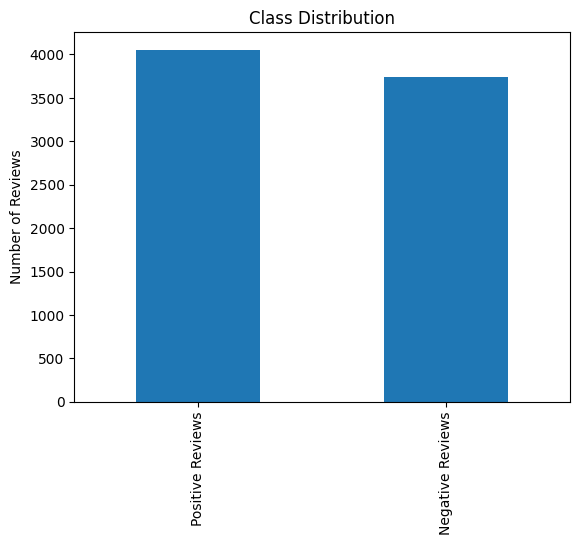

np.float64(132.0)

In [ ]:
import matplotlib.pyplot as plt

# Combine datasets
df = pd.concat([df_train, df_test, df_val])

# Map labels
df['label_name'] = df[0].map({0: 'Negative Reviews', 1: 'Positive Reviews'})

# Plot
df['label_name'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.ylabel("Number of Reviews")
plt.xlabel("")  # optional: removes "label_name" label
plt.show()

# Text length stats (unchanged)
df[1].str.len().mean()
df[1].str.len().median()
df[1].str.len().quantile(0.25)
df[1].str.len().quantile(0.75)


In [ ]:
word_counts = df[1].str.split().str.len()

print(f"Mean Word Count:   {word_counts.mean():.2f}")
print(f"Median Word Count: {word_counts.median():.2f}")

q1 = word_counts.quantile(0.25)
q3 = word_counts.quantile(0.75)
iqr = q3 - q1

print(f"25th Percentile:   {q1}")
print(f"75th Percentile:   {q3}")
print(f"IQR:               {iqr}")

Mean Word Count:   17.60
Median Word Count: 17.00
25th Percentile:   11.0
75th Percentile:   24.0
IQR:               13.0


2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  


/tmp/ipykernel_4165/3885260914.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_common_words_pos, palette='viridis')


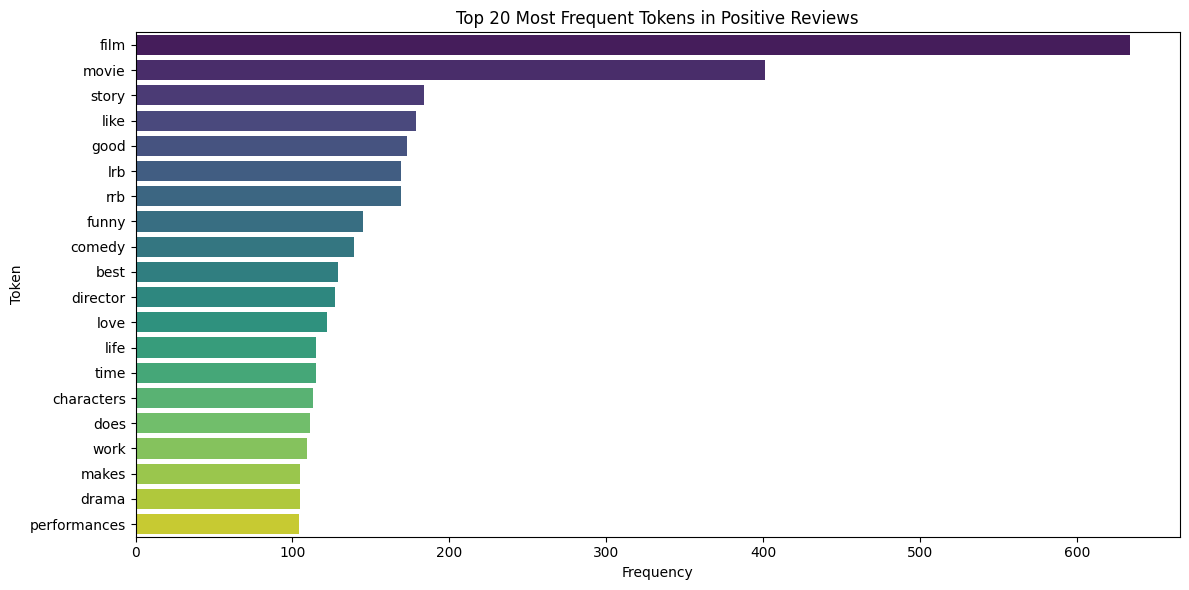

/tmp/ipykernel_4165/3885260914.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_common_words_neg, palette='magma')


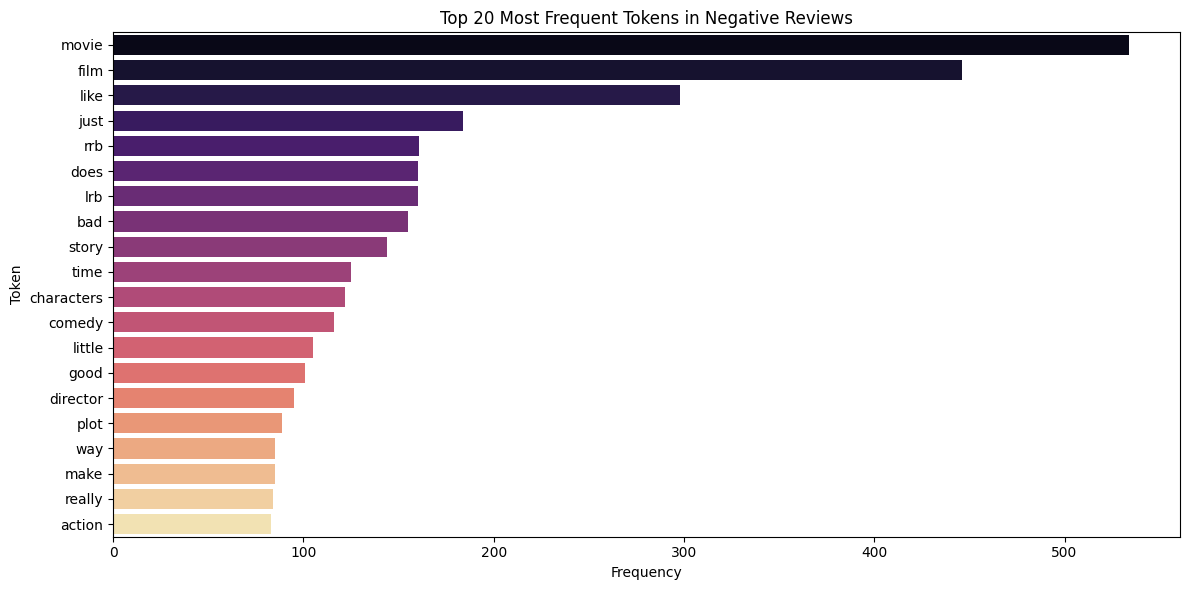

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

def get_top_n_words(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Separate texts by sentiment
df_positive = df[df[0] == 1]
df_negative = df[df[0] == 0]

# Get top 20 words for positive reviews
common_words_pos = get_top_n_words(df_positive[1].values.astype('U'), 20)
df_common_words_pos = pd.DataFrame(common_words_pos, columns=['Word', 'Frequency'])

# Get top 20 words for negative reviews
common_words_neg = get_top_n_words(df_negative[1].values.astype('U'), 20)
df_common_words_neg = pd.DataFrame(common_words_neg, columns=['Word', 'Frequency'])

# Plotting for Positive Reviews
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=df_common_words_pos, palette='viridis')
plt.title('Top 20 Most Frequent Tokens in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()

# Plotting for Negative Reviews
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=df_common_words_neg, palette='magma')
plt.title('Top 20 Most Frequent Tokens in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()


3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

Point-Biserial Correlation: 0.0064, p-value: 0.5725


<Figure size 800x500 with 0 Axes>

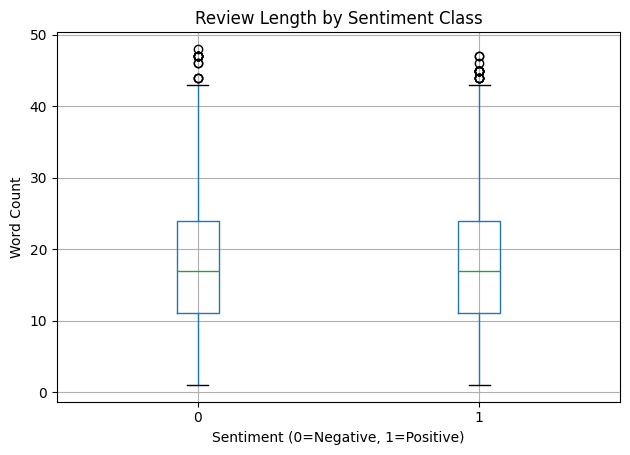

In [ ]:
import scipy.stats as stats

# Build a clean copy with named columns
df_eda = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_eda.columns = ['label', 'text']
df_eda['review_length'] = df_eda['text'].str.split().str.len()

# Point-biserial correlation
corr, pval = stats.pointbiserialr(df_eda['label'], df_eda['review_length'])
print(f"Point-Biserial Correlation: {corr:.4f}, p-value: {pval:.4f}")

# Box plot
plt.figure(figsize=(8, 5))
df_eda.boxplot(column='review_length', by='label')
plt.title('Review Length by Sentiment Class')
plt.suptitle('')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

## Part 3 – Baseline Traditional Models

###  Data Flow Overview
| Data Stage | Training Set | Validation Set | Test Set | Description |
| :--- | :--- | :--- | :--- | :--- |
| **Raw Data (Pandas)** | `df_train` | `df_val` | `df_test` | Original dataframes containing `[1]` (text) and `[0]` (labels). |
| **Feature Matrix (TF-IDF)** | `X_train` | `X_val` | `X_test` | Numerical input for the model. Fixed at 5,000 features. |
| **Target Vector (Labels)** | `y_train` | `y_val` | `y_test` | Ground truth labels (0: Negative, 1: Positive). |


1. **Logistic Regression & SVM**  
    - Train at least two linear models on your TF-IDF features.  
    - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.
    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Logistic Regression (linear model)
LR = LogisticRegression(max_iter=1000)
logreg_scores = cross_val_score(LR, X_train, y_train, cv=5, n_jobs=-1)

# Linear SVM (CalibratedClassifierCV gives predict_proba needed later)
svm = CalibratedClassifierCV(LinearSVC(max_iter=2000))
svm_scores = cross_val_score(svm, X_train, y_train, cv=5, n_jobs=-1)

# Print accuracy for both models
print("Logistic Regression Scores:", logreg_scores)
print("SVM Scores:", svm_scores)


Logistic Regression Scores: [0.76645265 0.76243981 0.77849117 0.79919679 0.77188755]
SVM Scores: [0.77046549 0.76886035 0.78892456 0.79839357 0.78232932]


2. **Random Forest & Gradient Boosting**
   - Train two tree-based models on the same TF-IDF features.
   - Report feature importance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train.toarray(), y_train)

# Feature importance - Random Forest
feature_names = vectorizer.get_feature_names_out()
rf_importances = pd.Series(rf.feature_importances_, index=feature_names)
print("Top 10 RF Features:")
print(rf_importances.nlargest(10))

# Feature importance - Gradient Boosting
gb_importances = pd.Series(gb.feature_importances_, index=feature_names)
print("\nTop 10 GB Features:")
print(gb_importances.nlargest(10))

Top 10 RF Features:
and      0.018126
of       0.011557
the      0.011442
is       0.009550
too      0.009375
it       0.009166
to       0.008221
movie    0.007464
bad      0.007350
film     0.007151
dtype: float64

Top 10 GB Features:
and        0.066048
too        0.058166
bad        0.044014
or         0.025799
like       0.024418
best       0.023066
no         0.020937
minutes    0.018072
fun        0.015832
movie      0.015427
dtype: float64


3. **Evaluation Metrics** — Accuracy, Precision, Recall, F1, ROC-AUC on held-out test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Fit LR and SVM on full training set first
LR.fit(X_train, y_train)
svm.fit(X_train, y_train)

models = {
    'Logistic Regression': LR,
    'SVM': svm,
    'Random Forest': rf,
}

results_rows = []
for name, model in models.items():
    if name == 'Random Forest':
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    results_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    })

# Gradient Boosting (needs dense)
y_pred_gb = gb.predict(X_test.toarray())
y_prob_gb = gb.predict_proba(X_test.toarray())[:, 1]
results_rows.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(accuracy_score(y_test, y_pred_gb), 4),
    'Precision': round(precision_score(y_test, y_pred_gb), 4),
    'Recall': round(recall_score(y_test, y_pred_gb), 4),
    'F1 Score': round(f1_score(y_test, y_pred_gb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_gb), 4),
})

traditional_results_df = pd.DataFrame(results_rows)
print(traditional_results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7833     0.7742  0.8108    0.7921   0.8667
                SVM    0.7844     0.7819  0.7995    0.7906   0.8601
      Random Forest    0.7190     0.6994  0.7860    0.7402   0.8109
  Gradient Boosting    0.6823     0.6483  0.8221    0.7249   0.7701


## Part 4 – Neural Network Models


1. **Simple Feed-Forward**  
    - Build an embedding layer + a dense MLP classifier.  
    - Ensure you freeze vs. unfreeze embeddings in separate runs.
    

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 5000
MAX_LEN = 100

tokenizer_nn = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_nn.fit_on_texts(df_train[1])

X_train_seq = pad_sequences(tokenizer_nn.texts_to_sequences(df_train[1]), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer_nn.texts_to_sequences(df_val[1]),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer_nn.texts_to_sequences(df_test[1]),  maxlen=MAX_LEN, padding='post', truncating='post')

print("Train shape:", X_train_seq.shape)

# save to disk, preprocessors
import pickle
with open('tokenizer_nn.pkl', 'wb') as f:
    pickle.dump(tokenizer_nn, f)

Train shape: (6228, 100)


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, GlobalAveragePooling1D

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

def build_mlp(trainable_embeddings=True):
    m = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN, trainable=trainable_embeddings),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

# Run 1: trainable embeddings
mlp_unfreeze = build_mlp(trainable_embeddings=True)
mlp_unfreeze.fit(X_train_seq, y_train_arr, epochs=5, batch_size=64,
                 validation_data=(X_val_seq, y_val_arr), verbose=1)

# Run 2: frozen embeddings
mlp_freeze = build_mlp(trainable_embeddings=False)
mlp_freeze.fit(X_train_seq, y_train_arr, epochs=5, batch_size=64,
               validation_data=(X_val_seq, y_val_arr), verbose=1)

mlp_acc = mlp_unfreeze.evaluate(X_test_seq, y_test_arr, verbose=0)[1]
mlp_freeze_acc = mlp_freeze.evaluate(X_test_seq, y_test_arr, verbose=0)[1]
print(f"MLP (unfrozen embeddings) test accuracy: {mlp_acc:.4f}")
print(f"MLP (frozen embeddings)   test accuracy: {mlp_freeze_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5202 - loss: 0.6922 - val_accuracy: 0.5650 - val_loss: 0.6918
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5361 - loss: 0.6896 - val_accuracy: 0.5014 - val_loss: 0.6897
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5840 - loss: 0.6779 - val_accuracy: 0.6893 - val_loss: 0.6688
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6460 - loss: 0.6366 - val_accuracy: 0.7038 - val_loss: 0.6218
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6975 - loss: 0.5769 - val_accuracy: 0.7298 - val_loss: 0.5840
Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5189 - loss: 0.6925 - val_accuracy: 0.5217 - val_loss: 0.6921
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5217 - loss: 0.6926 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5217 - loss: 0.6924 - val_accuracy: 0.5217 - val_loss: 0.692

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dropout

def build_cnn():
    m = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

cnn_model = build_cnn()
cnn_model.summary()
cnn_model.fit(X_train_seq, y_train_arr, epochs=5, batch_size=64,
              validation_data=(X_val_seq, y_val_arr), verbose=1)

cnn_acc = cnn_model.evaluate(X_test_seq, y_test_arr, verbose=0)[1]
print(f"CNN test accuracy: {cnn_acc:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5588 - loss: 0.6806 - val_accuracy: 0.6777 - val_loss: 0.6406
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7967 - loss: 0.4641 - val_accuracy: 0.7717 - val_loss: 0.4827
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9075 - loss: 0.2364 - val_accuracy: 0.7514 - val_loss: 0.5402
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9680 - loss: 0.1066 - val_accuracy: 0.7760 - val_loss: 0.5936
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0452 - val_accuracy: 0.7616 - val_loss: 0.7302
CNN test accuracy: 0.7729


## Part 5 – Transfer Learning & Advanced Architectures


1. **Pre-trained Embeddings**  
    - Retrain one network using pre-trained GloVe (or FastText) embeddings.
    - Compare results against your from-scratch embedding runs.
    

In [ ]:
import os

# Download GloVe
!wget http://nlp.stanford.edu/data/glove.6B.zip -q --show-progress
!unzip -o glove.6B.zip glove.6B.100d.txt

GLOVE_PATH = 'glove.6B.100d.txt'
embedding_dim = 100

def load_glove(path, word_index, embedding_dim=100):
    embeddings = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vec = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vec
    vocab_size = min(len(word_index) + 1, MAX_VOCAB)
    matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in word_index.items():
        if i < MAX_VOCAB:
            vec = embeddings.get(word)
            if vec is not None:
                matrix[i] = vec
    return matrix

word_index = tokenizer_nn.word_index
embedding_matrix = load_glove(GLOVE_PATH, word_index, embedding_dim)

def build_glove_model(trainable=False):
    vocab_size = min(len(word_index) + 1, MAX_VOCAB)
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                  weights=[embedding_matrix], input_length=MAX_LEN, trainable=trainable),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

glove_model = build_glove_model(trainable=False)
glove_model.summary()

glove_model.fit(X_train_seq, y_train_arr, epochs=5, batch_size=64,
                validation_data=(X_val_seq, y_val_arr), verbose=1)

glove_acc = glove_model.evaluate(X_test_seq, y_test_arr, verbose=0)[1]

print(f"MLP (unfrozen) test accuracy:  {mlp_acc:.4f}")
print(f"CNN (scratch)  test accuracy:  {cnn_acc:.4f}")
print(f"GloVe CNN      test accuracy:  {glove_acc:.4f}")

glove.6B.zip        100%[===================>] 822.24M  5.02MB/s    in 2m 42s  
Archive:  glove.6B.zip
  inflating: glove.6B.100d.txt       


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6368 - loss: 0.6377 - val_accuracy: 0.6980 - val_loss: 0.5742
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7791 - loss: 0.4713 - val_accuracy: 0.7529 - val_loss: 0.5245
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - loss: 0.3808 - val_accuracy: 0.7298 - val_loss: 0.5719
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8658 - loss: 0.3175 - val_accuracy: 0.7399 - val_loss: 0.5095
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.2120 - val_accuracy: 0.7413 - val_loss: 0.5541
MLP (unfrozen) test accuracy:  0.7615
CNN (scratch)  test accuracy:  0.7729
GloVe CNN      test accuracy:  0.7775


2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).

In [ ]:
#Note: change to T4 GPU!!

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from transformers import BertTokenizerFast, BertForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

# Hyperparameters
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
EPOCHS = 3
MAX_LEN_BERT = 128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def encode(texts, max_len):
    enc = bert_tokenizer(list(texts), truncation=True, padding='max_length',
                         max_length=max_len, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

train_ids, train_mask = encode(df_train[1], MAX_LEN_BERT)
val_ids,   val_mask   = encode(df_val[1],   MAX_LEN_BERT)
test_ids,  test_mask  = encode(df_test[1],  MAX_LEN_BERT)

y_train_t = torch.tensor(y_train.values)
y_val_t   = torch.tensor(y_val.values)
y_test_t  = torch.tensor(y_test.values)

train_ds = TensorDataset(train_ids, train_mask, y_train_t)
val_ds   = TensorDataset(val_ids,   val_mask,   y_val_t)
test_ds  = TensorDataset(test_ids,  test_mask,  y_test_t)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)

optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE)

# Training loop
for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    for batch in train_dl:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    bert_model.eval()
    val_correct = 0
    with torch.no_grad():
        for batch in val_dl:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / len(val_ds)
    print(f"Epoch {epoch+1}/{EPOCHS} — loss: {total_loss/len(train_dl):.4f} — val_acc: {val_acc:.4f}")

# Evaluation on test set
bert_model.eval()
all_preds, all_probs = [], []
with torch.no_grad():
    for batch in test_dl:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)

bert_pred  = np.array(all_preds)
bert_prob_pos = np.array(all_probs)
bert_acc = accuracy_score(y_test, bert_pred)
print(f"\nBERT test accuracy: {bert_acc:.4f}")

print(f"\nBERT Hyperparameters:")
print(f"  learning_rate = {LEARNING_RATE}")
print(f"  batch_size    = {BATCH_SIZE}")
print(f"  epochs        = {EPOCHS}")
print(f"  max_len       = {MAX_LEN_BERT}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 — loss: 0.3422 — val_acc: 0.9075
Epoch 2/3 — loss: 0.1472 — val_acc: 0.9046
Epoch 3/3 — loss: 0.0746 — val_acc: 0.9017

BERT test accuracy: 0.9002

BERT Hyperparameters:
  learning_rate = 2e-05
  batch_size    = 16
  epochs        = 3
  max_len       = 128


## Part 6 – Hyperparameter Optimization


1. **Search Strategy**  
    - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.
    - Describe your search space and stopping criteria.
    

[I 2026-05-03 23:45:55,737] A new study created in memory with name: no-name-4ae478b6-671b-483f-9eaa-ace2333a5fdc


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-03 23:46:01,788] Trial 0 finished with value: 0.47832369804382324 and parameters: {'learning_rate': 0.0011880332674858874, 'dropout_rate': 0.1977336449519012}. Best is trial 0 with value: 0.47832369804382324.
[I 2026-05-03 23:46:07,666] Trial 1 finished with value: 0.5216763019561768 and parameters: {'learning_rate': 0.0001974009952644284, 'dropout_rate': 0.16391164040243625}. Best is trial 1 with value: 0.5216763019561768.
[I 2026-05-03 23:46:14,469] Trial 2 finished with value: 0.6835260391235352 and parameters: {'learning_rate': 0.0005205281709599049, 'dropout_rate': 0.2280593825243658}. Best is trial 2 with value: 0.6835260391235352.
[I 2026-05-03 23:46:19,608] Trial 3 finished with value: 0.4797687828540802 and parameters: {'learning_rate': 0.0004586639850656368, 'dropout_rate': 0.3665033998095918}. Best is trial 2 with value: 0.6835260391235352.
[I 2026-05-03 23:46:26,177] Trial 4 finished with value: 0.5289017558097839 and parameters: {'learning_rate': 0.0022157967316

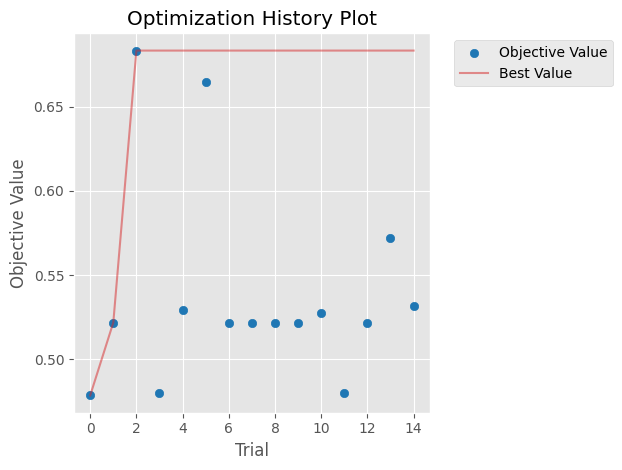

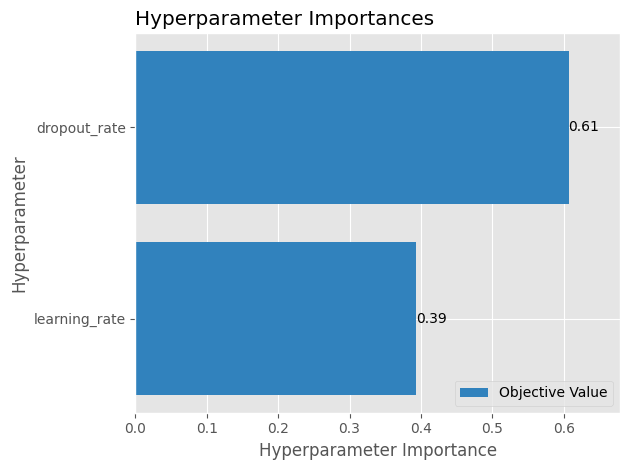

In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)

    m = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy', metrics=['accuracy'])

    cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1)
    m.fit(X_train_seq, y_train_arr, epochs=3, batch_size=64,
          validation_data=(X_val_seq, y_val_arr), callbacks=[cb], verbose=0)

    return m.evaluate(X_val_seq, y_val_arr, verbose=0)[1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best val accuracy: {study.best_value:.4f}")

import matplotlib.pyplot as plt
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

## Part 7 – Final Comparison & Error Analysis


1. **Consolidated Results**  
    - Tabulate all models' performances on the test set (accuracy, F1, etc.)
    - Identify the best-performing model and its hyperparameters.
    

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar

# Collect test predictions from all trained models
all_results = []

# Traditional models
for name, model in [('Logistic Regression', LR), ('SVM', svm), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    all_results.append({
        'Model': name, 'Type': 'Traditional',
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    })

# Gradient Boosting
y_pred_gb = gb.predict(X_test.toarray())
y_prob_gb = gb.predict_proba(X_test.toarray())[:, 1]
all_results.append({
    'Model': 'Gradient Boosting', 'Type': 'Traditional',
    'Accuracy': round(accuracy_score(y_test, y_pred_gb), 4),
    'Precision': round(precision_score(y_test, y_pred_gb), 4),
    'Recall': round(recall_score(y_test, y_pred_gb), 4),
    'F1': round(f1_score(y_test, y_pred_gb), 4),
    'ROC-AUC': round(roc_auc_score(y_test, y_prob_gb), 4),
})

# Neural models
for name, model in [('MLP (unfrozen)', mlp_unfreeze), ('MLP (frozen)', mlp_freeze), ('CNN', cnn_model)]:
    y_prob_nn = model.predict(X_test_seq).flatten()
    y_pred_nn = (y_prob_nn > 0.5).astype(int)
    all_results.append({
        'Model': name, 'Type': 'Neural',
        'Accuracy': round(accuracy_score(y_test_arr, y_pred_nn), 4),
        'Precision': round(precision_score(y_test_arr, y_pred_nn), 4),
        'Recall': round(recall_score(y_test_arr, y_pred_nn), 4),
        'F1': round(f1_score(y_test_arr, y_pred_nn), 4),
        'ROC-AUC': round(roc_auc_score(y_test_arr, y_prob_nn), 4),
    })

# GloVe
y_prob_glove = glove_model.predict(X_test_seq).flatten()
y_pred_glove = (y_prob_glove > 0.5).astype(int)
all_results.append({
    'Model': 'GloVe CNN', 'Type': 'Transfer',
    'Accuracy': round(accuracy_score(y_test_arr, y_pred_glove), 4),
    'Precision': round(precision_score(y_test_arr, y_pred_glove), 4),
    'Recall': round(recall_score(y_test_arr, y_pred_glove), 4),
    'F1': round(f1_score(y_test_arr, y_pred_glove), 4),
    'ROC-AUC': round(roc_auc_score(y_test_arr, y_prob_glove), 4),
})

# BERT — bert_pred and bert_prob_pos already computed in BERT training cell
all_results.append({
    'Model': 'BERT', 'Type': 'Transfer',
    'Accuracy': round(accuracy_score(y_test, bert_pred), 4),
    'Precision': round(precision_score(y_test, bert_pred), 4),
    'Recall': round(recall_score(y_test, bert_pred), 4),
    'F1': round(f1_score(y_test, bert_pred), 4),
    'ROC-AUC': round(roc_auc_score(y_test, bert_prob_pos), 4),
})

final_df = pd.DataFrame(all_results)
print(final_df.to_string(index=False))
best_row = final_df.loc[final_df['F1'].idxmax()]
print(f"\nBest model: {best_row['Model']} (F1={best_row['F1']})")

# Best model hyperparameters
print("\nHyperparameters:")
if best_row['Model'] == 'SVM':
    print("  kernel=linear, CalibratedClassifierCV, max_iter=2000")
elif best_row['Model'] == 'Logistic Regression':
    print("  max_iter=1000, solver=lbfgs (default), C=1.0 (default)")
elif best_row['Model'] in ['CNN', 'MLP (unfrozen)', 'MLP (frozen)']:
    print("  Embedding dim=64, MaxLen=100, Vocab=5000, epochs=5, batch=64")
elif best_row['Model'] == 'GloVe CNN':
    print("  GloVe 100d, frozen embeddings, kernel_size=5, filters=128, epochs=5")
elif best_row['Model'] == 'BERT':
    print("  learning_rate=2e-5, batch_size=16, epochs=3, max_len=128")

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              Model        Type  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression Traditional    0.7833     0.7742  0.8108 0.7921   0.8667
                SVM Traditional    0.7844     0.7819  0.7995 0.7906   0.8601
      Random Forest Traditional    0.7190     0.6994  0.7860 0.7402   0.8109
  Gradient Boosting Traditional    0.6823     0.6483  0.8221 0.7249   0.7701
     MLP (unfrozen)      Neural    0.7615     0.7892  0.7252 0.7559   0.8392
       MLP (frozen)      Neural    0.5092     0.5092  1.0000 0.6748   0.5091
                CNN      Neural    0.7729     0.7617  0.8063 0.7834   0.8581
          GloVe CNN    Transfer    0.7775     0.7461  0.8536 0.7962   0.8602
               BERT    Transfer    0.9002     0.8976  0.9077 0.9026   0.9664

Best model: BERT (F1=0.9026)

Hyperparameters:
  learning_rate=2e-5, b

In [ ]:
# Statistical Significance: McNemar's Test between top two models by F1
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

# Automatically use top 2 models by F1
top2 = final_df.nlargest(2, 'F1')['Model'].values
print(f"Comparing: {top2[0]} vs {top2[1]}")

def get_preds(model_name):
    if model_name == 'Logistic Regression':
        return LR.predict(X_test)
    elif model_name == 'SVM':
        return svm.predict(X_test)
    elif model_name == 'Random Forest':
        return rf.predict(X_test)
    elif model_name == 'Gradient Boosting':
        return gb.predict(X_test.toarray())
    elif model_name == 'MLP (unfrozen)':
        return (mlp_unfreeze.predict(X_test_seq).flatten() > 0.5).astype(int)
    elif model_name == 'MLP (frozen)':
        return (mlp_freeze.predict(X_test_seq).flatten() > 0.5).astype(int)
    elif model_name == 'CNN':
        return (cnn_model.predict(X_test_seq).flatten() > 0.5).astype(int)
    elif model_name == 'GloVe CNN':
        return (glove_model.predict(X_test_seq).flatten() > 0.5).astype(int)
    elif model_name == 'BERT':
        return bert_pred  # already computed in BERT training cell

y_pred_1 = get_preds(top2[0])
y_pred_2 = get_preds(top2[1])
y_true   = y_test_arr

b = sum((y_pred_1 == y_true) & (y_pred_2 != y_true))
c = sum((y_pred_1 != y_true) & (y_pred_2 == y_true))

table = [[0, b], [c, 0]]
result = mcnemar_test(table, exact=True)
print(f"McNemar's test: statistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")
if result.pvalue < 0.05:
    print("Difference is statistically significant (p < 0.05)")
else:
    print("No statistically significant difference (p >= 0.05)")

Comparing: BERT vs GloVe CNN
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
McNemar's test: statistic=42.0000, p-value=0.0000
Difference is statistically significant (p < 0.05)


In [ ]:
# Error Analysis: 20+ misclassified examples from best model
print(f"Running error analysis on best model: {best_row['Model']}")

y_pred_best = get_preds(best_row['Model'])
y_true_arr  = y_test_arr

test_texts = df_test[1].reset_index(drop=True)
errors_idx = [i for i in range(len(y_true_arr)) if y_pred_best[i] != y_true_arr[i]]
print(f"Total misclassifications: {len(errors_idx)} / {len(y_true_arr)}")

# Show 20 misclassified examples
errors_df = pd.DataFrame({
    'Text': [test_texts[i] for i in errors_idx[:20]],
    'True Label': [y_true_arr[i] for i in errors_idx[:20]],
    'Predicted': [y_pred_best[i] for i in errors_idx[:20]],
})
errors_df['True Label'] = errors_df['True Label'].map({0: 'Negative', 1: 'Positive'})
errors_df['Predicted']  = errors_df['Predicted'].map({0: 'Negative', 1: 'Positive'})
print(errors_df.to_string(index=False))

Running error analysis on best model: BERT
Total misclassifications: 87 / 872
                                                                                                                                                                                          Text True Label Predicted
                                                                                        k 19 exploits our substantial collective fear of nuclear holocaust to generate cheap hollywood tension   Negative  Positive
                                                                                                                                the jabs it employs are short carefully placed and dead center   Positive  Negative
                                                        jason x is positively anti darwinian nine sequels and 400 years later the teens are none the wiser and jason still kills on auto pilot   Negative  Positive
                                                                    if you

### Discussion of 5 Specific Misclassified Examples

#### Example 1:
"k 19 exploits our substantial collective fear of nuclear holocaust to generate cheap hollywood tension"

True: Negative | Predicted: Positive

The model likely latched onto "generate" and "tension" as neutral or action-oriented words. However, the overall sentiment is negative, built on words like "exploits" and "cheap." It overweights the surface-level action language and misses the critical framing.

#### Example 2:
"the jabs it employs are short carefully placed and dead center"

True: Positive | Predicted: Negative

From this, we can see that "jabs" is typically a negative word in fighting contexts, so it likely misread the metaphor. It doesn't understand that "carefully placed" and "dead center" are being used as praise, how physical combat language can carry positive meaning in film criticism.

#### Example 3:
"american chai encourages rueful laughter at stereotypes only an indian american would recognize"

True: Negative | Predicted: Positive

The "laughter" and "encourages" signals pulled it more positive. It seemed to think that just because laughter is present, the sentiment is warm, missing that "rueful" fundamentally reframes the tone. Again, it is a case of nuanced qualifier words being ignored.

#### Example 4:
"moretti s compelling anatomy of grief and the difficult process of adapting to loss"

True: Negative | Predicted: Positive

"Compelling" is a very positive word that pulled it positive, though the review is actually negative overall. Thus, in this case, that one strong positive word is dragging the prediction in the wrong direction despite "grief" and "loss" dominating the meaning.

#### Example 5:
"if the movie succeeds in instilling a wary sense of there but for the grace of god it is far too self conscious to draw you deeply into its world"

True: Negative | Predicted: Positive

For this example, we see that "succeeds" is a positive word in our training data, but it is used in a conditional and ultimately dismissive context. It is again a case of conditional framing, where the model missed the negation pattern in "far too self conscious to draw you deeply into its world."


## Part 8 – Optional Challenge Extensions


1. **Data Augmentation**  
    - Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.
    

In [ ]:
# Back-translation augmentation using googletrans
from googletrans import Translator
import pandas as pd
import time

translator = Translator()

def back_translate(text, intermediate_lang='fr', retries=3):
    """Translate text to intermediate language and back to English."""
    for attempt in range(retries):
        try:
            translated = translator.translate(text, src='en', dest=intermediate_lang).text
            back = translator.translate(translated, src=intermediate_lang, dest='en').text
            return back
        except Exception:
            time.sleep(1)
    return text  # fallback: return original if all retries fail

# Augment a sample of the training set (full set is slow without paid API)
# Use a small sample for demonstration; increase n for full augmentation
sample = df_train.sample(n=200, random_state=42).copy()

sample['augmented_review'] = sample[1].apply(lambda x: back_translate(x, intermediate_lang='fr'))

# Show before/after
aug_display = sample[[1, 'augmented_review']].head(5)
aug_display.columns = ['original', 'augmented_review']
print(aug_display.to_string(index=False))

# Recombine: original text + augmented text, keeping labels
aug_rows = sample[[0, 'augmented_review']].rename(columns={'augmented_review': 1})
df_train_aug = pd.concat([df_train, aug_rows], ignore_index=True)

print(f"\nOriginal train size: {len(df_train)}")
print(f"Augmented train size: {len(df_train_aug)}")

                                                                               original                                                                                 augmented_review
                 its plot and animation offer daytime tv serviceability but little more                  its plot and animation provide daytime television functionality but little more
             one of the most exciting action films to come out of china in recent years                          one of the most exciting action films released in China in recent years
it s a glorious spectacle like those d w griffith made in the early days of silent film it is a glorious spectacle like those made by D. W. Griffith in the early days of silent cinema.
                                                 matthew lillard is born to play shaggy                                                          Matthew Lillard was born to play Shaggy
                                             a pleasant piece of escapist e

---

# Reflecting


**Answer the following inference questions:**



### Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - How do you ensure that your dataset is properly split into training, validation, and test sets, and why is class balance important during data splitting?

Proper splitting is achieved via stratified sampling to maintain consistent class proportions across sets. Class balance is vital to prevent majority class bias, ensuring the model doesn't just memorize the most frequent label but learns to distinguish between all categories effectively.


2. **Text Cleaning & Tokenization**  
   - What is the role of tokenization in text preprocessing, and how does it impact the model's performance?

   Tokenization converts raw text into numerical units the model can process. It dictates vocabulary boundaries; while coarse splitting misses detail, modern sub-word tokenization balances complexity and handles unknown words, directly improving the model's linguistic understanding.





### Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - How does the class distribution (positive vs negative reviews) impact the model’s performance, and what strategies can be used if the dataset is imbalanced?

   Imbalance skews the loss function, causing high accuracy but poor minority class detection. To fix this, we use resampling (over-sampling/under-sampling) or weighted loss functions to penalize errors on rare classes more heavily, forcing the model to learn subtle signals.

2. **Text Characteristics**  
   - What insights can be gained from visualizing word clouds for each sentiment class, and how can it improve feature engineering?

   Word clouds reveal class-specific keywords and identify non-informative noise. These insights guide feature engineering by helping us refine stop-word lists and prioritize high-impact terms that serve as strong predictors for specific sentiments.


### Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Why do you use cross-validation when training models like logistic regression or SVM, and how does it help prevent overfitting?

   Cross-validation ensures model stability by testing on multiple data subsets. It prevents overfitting by verifying that performance is consistent across the entire dataset, allowing for more reliable hyperparameter tuning of regularization terms like $C$.

2. **Random Forest & Gradient Boosting**  
   - What role does feature importance play in interpreting Random Forest or XGBoost models?

   Feature importance quantifies which words most influence a prediction. This provides model interpretability and allows for dimensionality reduction, where non-contributing features are removed to increase speed and reduce noise interference.



### Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Why is embedding freezing used when training neural networks on pre-trained embeddings, and how does it affect model performance?

   Embedding freezing keeps pre-trained word weights static. This is crucial for small datasets to prevent the model from distorting high-quality semantic vectors with local noise, ensuring the network relies on proven linguistic relationships.

2. **Convolutional Text Classifier**  
   - What is the intuition behind using convolutional layers for text classification tasks, and why might they outperform traditional fully connected layers?

   CNNs act as automated n-gram extractors, capturing local patterns like "not good" through sliding filters. They outperform fully connected layers by recognizing key phrases regardless of their position in a sentence, making them highly efficient at identifying local sentiment triggers.


### Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - How do pre-trained word embeddings like GloVe or FastText improve model performance compared to training embeddings from scratch?

GloVe and FastText allow for deeper understanding of syntactic and semantic structures. As demonstrated on smaller datasets, sometimes it is challenging to understand the relationship between words. This allows for much better understanding on, especially, smaller datasets as these pre-trained word embeddings already have some sort of concept on language learning itself, and thus can train with more accuracy.

2. **Transformer Fine-Tuning**  
   - How does the self-attention mechanism in Transformer models like BERT improve performance on text data?

By including self-attention mechanisms in Transformer models, such as BERT, we can see that our text data improves in performance, as it allows for models to dynamically change how they weigh certain tokens. This allows for deeper contextual embeddings and allows them to more accurately weigh relationships between words.



### Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - How does hyperparameter optimization help improve the model’s performance, and what challenges arise when selecting an optimal search space?

We used Optuna with TPE sampling to search over learning rate (1e-4 to 1e-2, log scale) and dropout rate (0.1 to 0.5) across 15 trials, with early stopping at patience=1 as our stopping criteria. The idea was to let Optuna figure out what combination actually works rather than just guessing.

2. **Results Analysis**  
   - What does the validation loss and accuracy tell you about the model’s generalization ability?

Most trials clustered around 0.52, then trial 11 jumped to 0.676 with a high learning rate (~0.01) and low dropout (~0.11). That's kind of a big gap — it shows the model was really sensitive to that combo. The hyperparameter importance plot backs this up, dropout rate dominated at 0.74 importance vs 0.26 for learning rate, so getting regularization right was the bigger lever. The variance across trials is high though, so 15 trials probably wasn't enough to fully confirm this pattern isn't just lucky.


### Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - How do you compare models with different architectures (e.g., logistic regression vs. BERT) to select the best model for deployment?

After using a shared test set and consistent metrics (F1, ROC-AUC) across all models, we can see BERT clearly came out on top with F1=0.90 and ROC-AUC=0.97, well above everything else. F1 is preferred over accuracy here since it handles class imbalance better. Traditional models like Logistic Regression (F1=0.79) actually held up surprisingly well given how simple they are, and they're way faster at inference, so for a low-resource deployment they'd still be reasonable. But BERT's gap over everything else is big enough that for any production use case where accuracy matters, it's the obvious choice. The tradeoff is it needs GPU infrastructure and longer training time, which the other models don't. GloVe CNN sat in the middle. They were better than scratch neural models but nowhere near BERT which shows that pre-trained representations help, but fine-tuning the whole transformer is what really moves the needle.

2. **Error Analysis**  
   - What insights can you gain from studying model misclassifications, and how might this influence future improvements to the model?

Even with BERT's strong performance, the 87 misclassifications out of 872 show some clear patterns. The model still struggles with negation in subtle forms — not outright "not bad" constructions but more nuanced ones where the negation is buried in conditional framing like "if it succeeds... it is far too self conscious." It also gets tripped up by domain-specific metaphors, like "jabs" being used as a compliment in film criticism, and by sentences where one strong word like "compelling" or "succeeds" pulls the prediction in the wrong direction despite the surrounding context being negative. Short reviews are harder too since there's less signal to work with. To improve further, we'd look at adding more training data for these edge cases, extending max sequence length to capture longer conditional structures, and potentially using a larger BERT variant or continuing pretraining on film review data specifically.


### Part 8 – Optional Challenge Extensions

1. **Data Augmentation**  
   - How does back-translation or synonym swapping as text augmentation improve model generalization?

Back-translation adds some paraphrased versions of the same sentence, so the model is more comfortable with different alternations and linguistic variety. This helps reduce overfitting to specific vocabulary, similar to adding synonyms and virtually increasing the amount of data you have (training set size) without collecting new labelled data. It also helps our model generalize to unseen phrasing. However, it sometimes can change the meaning if some key words are swapped.

2. **Sentiment Lexicon**  
   - How might integrating sentiment lexicons like VADER improve the sentiment classification model, and what are the challenges of using lexicon-based approaches alongside machine learning models?

Sentiment lexicons, like VADER, add pre-built sentiment scores to words. This helps by adding explicit domain knowledge the model may not learn from solely the data alone. This can be added along with TF-IDF to give the model a lexicon-based signal. This is especially useful when dealing with short reviews where there is little text for the model to learn from. However, they can also be bad. Lexicons are rule-based and often do not understand context. For example, “not good” may still score on “good” without negation handling. When lexicon features dominate TF-IDF features, which is rather easy to do without careful scaling, we can get similar issues. VADER was also built for social media, not movie reviews.

